In [1]:
import os
from pathlib import Path
import kagglehub

# Load KAGGLE_API_TOKEN from the repo-root .env

for line in (Path.cwd().parent / ".env").read_text().splitlines():
    key, _, value = line.strip().partition("=")
    if key and not key.startswith("#"):
        os.environ.setdefault(key, value.strip().strip("\"'"))

path = kagglehub.competition_download("GiveMeSomeCredit")
print(path, os.listdir(path))

C:\Users\Or\.cache\kagglehub\competitions\GiveMeSomeCredit ['cs-test.csv', 'cs-training.csv', 'Data Dictionary.xls', 'sampleEntry.csv']


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings 
warnings.filterwarnings("ignore")

In [3]:
dictionary_file = next(
    file for file in Path(path).glob("*")
    if file.suffix.lower() in {".xls", ".xlsx"}
)

data_dictionary_df = pd.read_excel(dictionary_file, header=0)
data_dictionary = data_dictionary_df

In [4]:
display(data_dictionary)

,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,Variable Name,Description,Type
1,SeriousDlqin2yrs,Person experienced 90 days past due delinquenc...,Y/N
2,RevolvingUtilizationOfUnsecuredLines,Total balance on credit cards and personal lin...,percentage
3,age,Age of borrower in years,integer
4,NumberOfTime30-59DaysPastDueNotWorse,Number of times borrower has been 30-59 days p...,integer
5,DebtRatio,"Monthly debt payments, alimony,living costs di...",percentage
6,MonthlyIncome,Monthly income,real
7,NumberOfOpenCreditLinesAndLoans,Number of Open loans (installment like car loa...,integer
8,NumberOfTimes90DaysLate,Number of times borrower has been 90 days or m...,integer
9,NumberRealEstateLoansOrLines,Number of mortgage and real estate loans inclu...,integer


In [5]:
import pandas as pd

train = pd.read_csv(os.path.join(path, "cs-training.csv"), index_col=0)
test = pd.read_csv(os.path.join(path, "cs-test.csv"), index_col=0)
print(f"train: {train.shape}, test: {test.shape}")
train.head()

train: (150000, 11), test: (101503, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [6]:
# Dataset shapes
print("Shapes:")
print(f"train: {train.shape}")
print(f"test:  {test.shape}")

Shapes:
train: (150000, 11)
test:  (101503, 11)


In [7]:
# Missing values
print("\nMissing values:")
display(pd.DataFrame({
    "train_missing": train.isna().sum(),
    "train_missing_pct": train.isna().mean().mul(100).round(2),
    "test_missing": test.isna().sum(),
    "test_missing_pct": test.isna().mean().mul(100).round(2),
}))



Missing values:


,train_missing,train_missing_pct,test_missing,test_missing_pct
SeriousDlqin2yrs,0,0.00,101503,100.00
RevolvingUtilizationOfUnsecuredLines,0,0.00,0,0.00
age,0,0.00,0,0.00
NumberOfTime30-59DaysPastDueNotWorse,0,0.00,0,0.00
DebtRatio,0,0.00,0,0.00
MonthlyIncome,29731,19.82,20103,19.81
NumberOfOpenCreditLinesAndLoans,0,0.00,0,0.00
NumberOfTimes90DaysLate,0,0.00,0,0.00
NumberRealEstateLoansOrLines,0,0.00,0,0.00
NumberOfTime60-89DaysPastDueNotWorse,0,0.00,0,0.00


In [8]:

# Descriptive statistics
print("\nTrain statistics:")
display(train.describe().T)


Train statistics:


,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


In [9]:
train['SeriousDlqin2yrs'].value_counts(dropna=False,normalize=True).rename("count").to_frame()

,count
SeriousDlqin2yrs,
0,0.93316
1,0.06684


In [10]:

# Categories / unique values
print("\nCategorical and low-cardinality columns:")
for column in train.columns:
    if train[column].nunique(dropna=False) <= 20:
        print(f"\n{column}:")
        display(train[column].value_counts(dropna=False).rename("count").to_frame())


Categorical and low-cardinality columns:

SeriousDlqin2yrs:


,count
SeriousDlqin2yrs,
0,139974
1,10026



NumberOfTime30-59DaysPastDueNotWorse:


,count
NumberOfTime30-59DaysPastDueNotWorse,
0,126018
1,16033
2,4598
3,1754
4,747
5,342
98,264
6,140
7,54



NumberOfTimes90DaysLate:


,count
NumberOfTimes90DaysLate,
0,141662
1,5243
2,1555
3,667
4,291
98,264
5,131
6,80
7,38



NumberOfTime60-89DaysPastDueNotWorse:


,count
NumberOfTime60-89DaysPastDueNotWorse,
0,142396
1,5731
2,1118
3,318
98,264
4,105
5,34
6,16
7,9



NumberOfDependents:


,count
NumberOfDependents,
0.0,86902
1.0,26316
2.0,19522
3.0,9483
NaN,3924
4.0,2862
5.0,746
6.0,158
7.0,51


## distributions

In [11]:
cols = train.columns.tolist()

## Data quality checks and cleaning

Before looking at distributions, check for issues that would otherwise distort every
downstream plot and statistic: exact duplicate rows, an impossible `age == 0`, and the
96/98 sentinel codes present in the three delinquency-count columns (these are
placeholder values, not real counts of "96 times late" — see `EDA_TEST_REPORT.md` for
the full statistical test results backing these choices).

In [12]:
print(f"Fully duplicate rows in train: {train.duplicated().sum()}")
print(f"Duplicate rows ignoring target: {train.drop(columns=['SeriousDlqin2yrs']).duplicated().sum()}")

train = train.drop_duplicates()
print(f"train shape after dropping exact duplicates: {train.shape}")

delinquency_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberOfTime60-89DaysPastDueNotWorse",
]


def clean_credit_df(df):
    df = df.copy()
    for col in delinquency_cols:
        df.loc[df[col].isin([96, 98]), col] = np.nan
    df.loc[df["age"] == 0, "age"] = np.nan
    return df


train_clean = clean_credit_df(train)
test_clean = clean_credit_df(test)
print(f"Sentinel (96/98) rows flagged as NaN: {train[delinquency_cols[0]].isin([96, 98]).sum()}")
print(f"Invalid age==0 rows flagged as NaN: {(train['age'] == 0).sum()}")

Fully duplicate rows in train: 609


Duplicate rows ignoring target: 646
train shape after dropping exact duplicates: (149391, 11)


Sentinel (96/98) rows flagged as NaN: 225


Invalid age==0 rows flagged as NaN: 1


## Univariate distributions: train vs. test

`RevolvingUtilizationOfUnsecuredLines`, `DebtRatio`, and `MonthlyIncome` are heavily
right-skewed with a small number of extreme outliers (see the data dictionary and
`EDA_TEST_REPORT.md` §2 for details), so those three are plotted on a log x-axis. Train
and test are drawn side by side for each column — a Kolmogorov-Smirnov test found no
significant train/test distributional shift on any feature (`EDA_TEST_REPORT.md` §4),
which the shapes below should visually confirm.

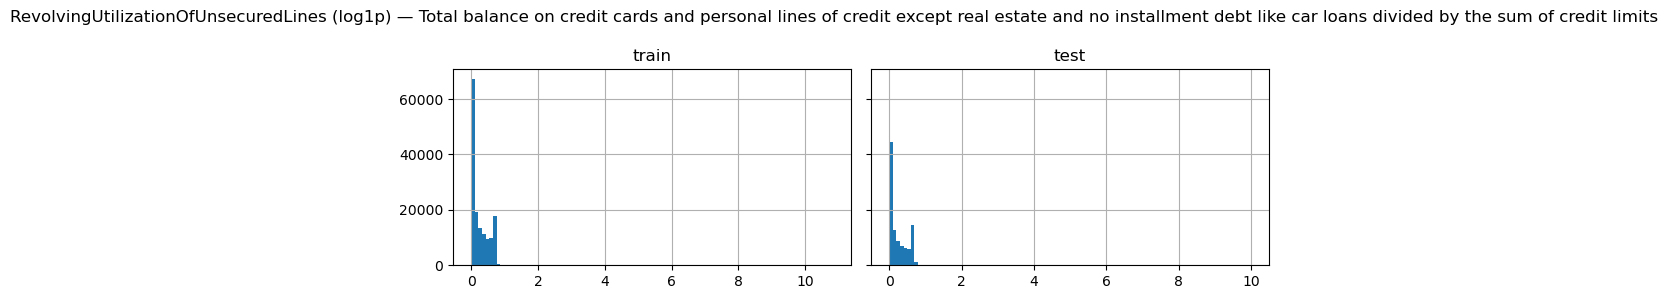

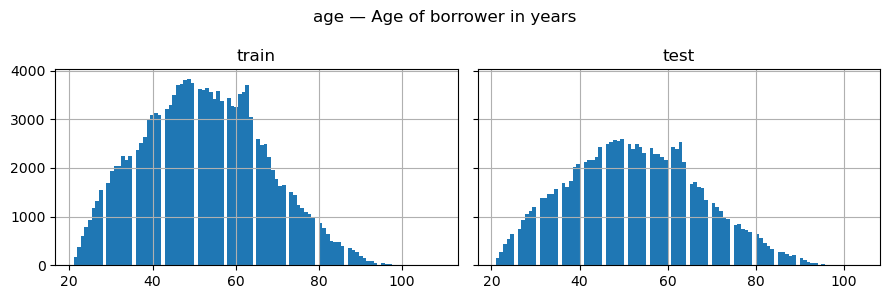

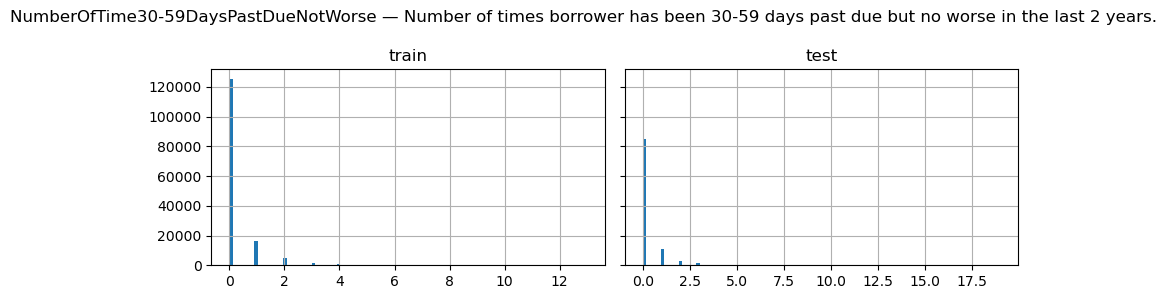

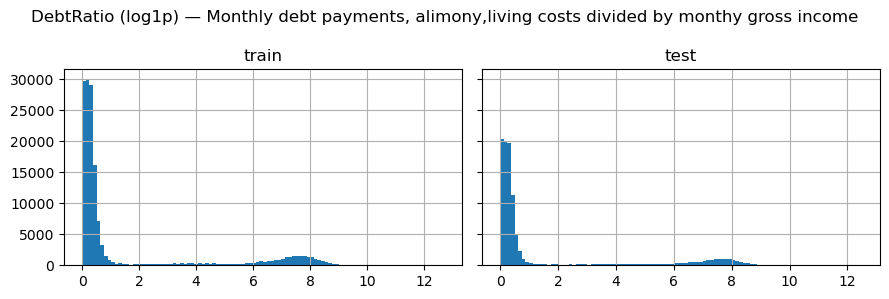

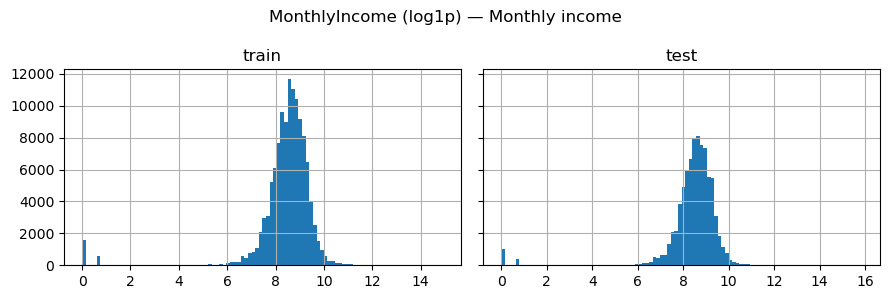

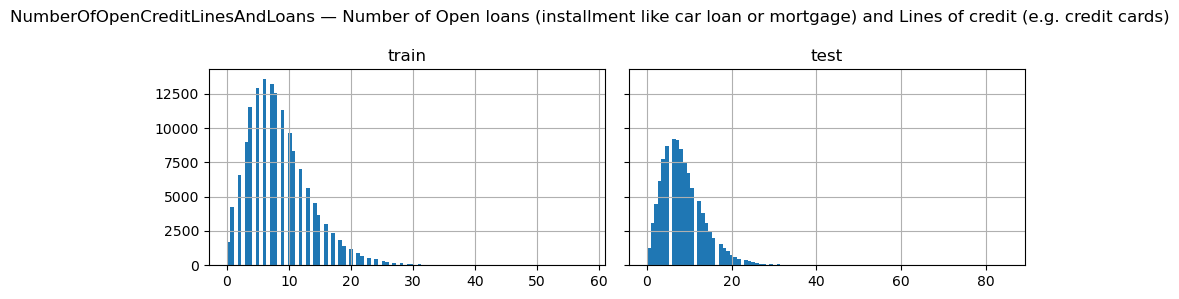

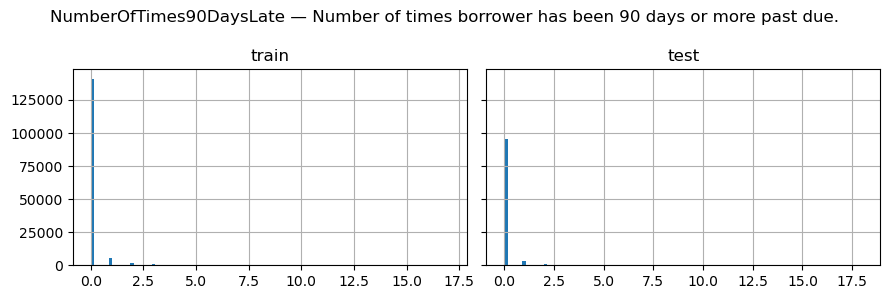

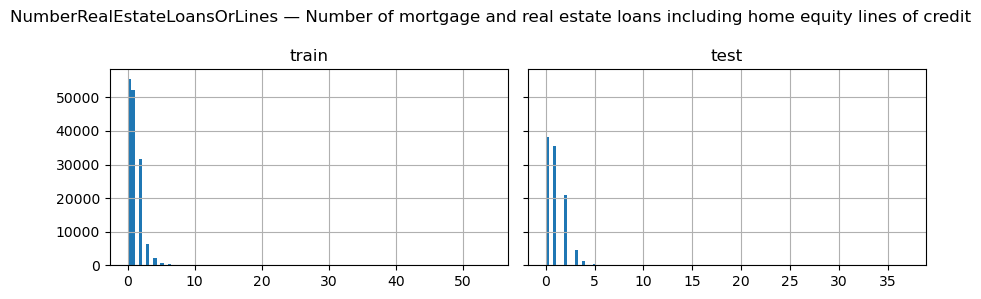

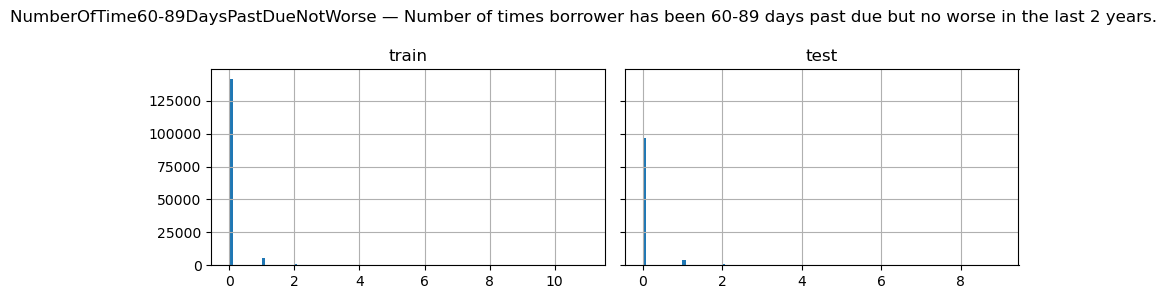

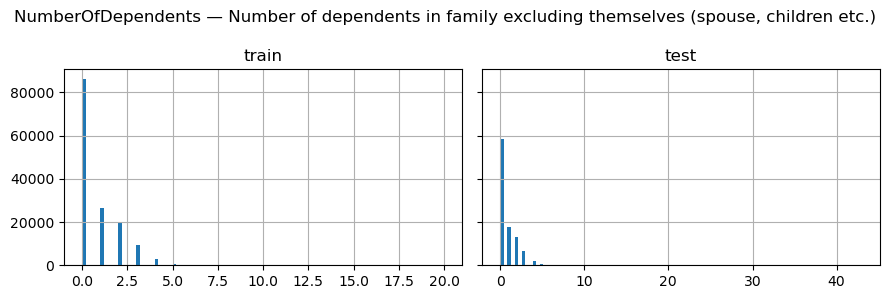

In [13]:
cols = [c for c in train.columns if c != "SeriousDlqin2yrs"]
log_scale_cols = {"RevolvingUtilizationOfUnsecuredLines", "DebtRatio", "MonthlyIncome"}

for col in cols:
    desc = data_dictionary.loc[data_dictionary.iloc[:, 0] == col, "Unnamed: 1"].values[0]
    fig, axes = plt.subplots(1, 2, figsize=(9, 3), sharey=True)
    for ax, (name, df) in zip(axes, [("train", train_clean), ("test", test_clean)]):
        series = df[col].dropna()
        if col in log_scale_cols:
            series = np.log1p(series)
        series.hist(bins=100, ax=ax)
        ax.set_title(name)
    fig.suptitle(f"{col}{' (log1p)' if col in log_scale_cols else ''} — {desc}")
    fig.tight_layout()

## Class imbalance

`SeriousDlqin2yrs` is ~93/7 non-delinquent vs. delinquent (see the value_counts above,
≈14:1). That ratio is large enough that plain accuracy is not a usable evaluation
metric downstream — AUC, PR-AUC, or recall-at-a-fixed-precision should be preferred,
and class weighting or resampling should be considered at training time.

Text(0, 0.5, 'share of rows')

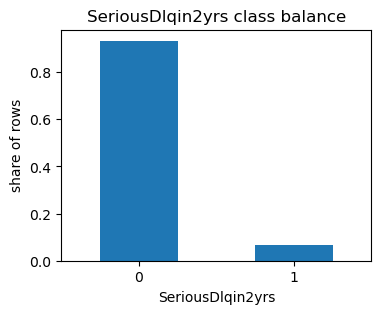

In [14]:
train["SeriousDlqin2yrs"].value_counts(normalize=True).sort_index().plot(
    kind="bar", figsize=(4, 3), title="SeriousDlqin2yrs class balance"
)
plt.xticks(rotation=0)
plt.ylabel("share of rows")

## Is missingness random?

`MonthlyIncome` (19.8%) and `NumberOfDependents` (2.6%) have missing values. Before
imputing, check whether missingness is related to other observed features: for each
column with missing values, compare every other feature's distribution between the
"missing" and "not missing" groups with a Mann-Whitney U test. If missingness were
purely random (MCAR), none of these should come out significant.

In [15]:
from scipy import stats

feature_cols = [c for c in train.columns if c != "SeriousDlqin2yrs"]

# Every row missing NumberOfDependents is also missing MonthlyIncome (but not vice
# versa) -- check that overlap explicitly before the per-feature tests below, since a
# feature that is 100% missing within one of the two groups breaks a Mann-Whitney test.
dep_missing = train["NumberOfDependents"].isna()
inc_missing = train["MonthlyIncome"].isna()
print(f"Rows missing NumberOfDependents: {dep_missing.sum()}")
print(f"  of those, also missing MonthlyIncome: {(dep_missing & inc_missing).sum()}")
print(f"Rows missing MonthlyIncome: {inc_missing.sum()}")
print(f"  of those, also missing NumberOfDependents: {(inc_missing & dep_missing).sum()}")

for missing_col in ["MonthlyIncome", "NumberOfDependents"]:
    is_missing = train[missing_col].isna()
    rows = []
    for col in feature_cols:
        if col == missing_col:
            continue
        a = train.loc[is_missing, col].dropna()
        b = train.loc[~is_missing, col].dropna()
        if len(a) == 0 or len(b) == 0:
            rows.append({"feature": col, "note": "fully missing in one group (see overlap check above)"})
            continue
        stat, p = stats.mannwhitneyu(a, b, alternative="two-sided")
        rows.append({
            "feature": col,
            "median | missing": a.median(),
            "median | not missing": b.median(),
            "mannwhitney_p": p,
            "significant (p<0.01)": p < 0.01,
        })
    print(f"\nMissingness check for {missing_col}:")
    display(pd.DataFrame(rows).set_index("feature"))

Rows missing NumberOfDependents: 3828
  of those, also missing MonthlyIncome: 3828
Rows missing MonthlyIncome: 29221
  of those, also missing NumberOfDependents: 3828



Missingness check for MonthlyIncome:


,median | missing,median | not missing,mannwhitney_p,significant (p<0.01)
feature,,,,
RevolvingUtilizationOfUnsecuredLines,0.08184,0.177261,7.720527e-284,True
age,57.00000,51.000000,0.000000e+00,True
NumberOfTime30-59DaysPastDueNotWorse,0.00000,0.000000,9.114775e-77,True
DebtRatio,1198.00000,0.296174,0.000000e+00,True
NumberOfOpenCreditLinesAndLoans,6.00000,8.000000,0.000000e+00,True
NumberOfTimes90DaysLate,0.00000,0.000000,1.235900e-01,False
NumberRealEstateLoansOrLines,1.00000,1.000000,8.563876e-140,True
NumberOfTime60-89DaysPastDueNotWorse,0.00000,0.000000,2.332314e-08,True
NumberOfDependents,0.00000,0.000000,0.000000e+00,True



Missingness check for NumberOfDependents:


,median | missing,median | not missing,mannwhitney_p,significant (p<0.01),note
feature,,,,,
RevolvingUtilizationOfUnsecuredLines,0.04767,0.158817,2.418829e-121,True,NaN
age,61.00000,52.000000,6.325243e-182,True,NaN
NumberOfTime30-59DaysPastDueNotWorse,0.00000,0.000000,6.260262e-23,True,NaN
DebtRatio,398.00000,0.359090,0.000000e+00,True,NaN
MonthlyIncome,NaN,NaN,NaN,NaN,fully missing in one group (see overlap check ...
NumberOfOpenCreditLinesAndLoans,5.00000,8.000000,0.000000e+00,True,NaN
NumberOfTimes90DaysLate,0.00000,0.000000,2.791464e-03,True,NaN
NumberRealEstateLoansOrLines,0.00000,1.000000,9.769919e-169,True,NaN
NumberOfTime60-89DaysPastDueNotWorse,0.00000,0.000000,3.797253e-07,True,NaN


## Correlation and multicollinearity

Spearman correlation (rank-based, robust to the outliers/skew seen above) between all
features, plus Variance Inflation Factors — VIF > 5 would suggest problematic
multicollinearity for linear models.

,VIF
NumberOfOpenCreditLinesAndLoans,1.276680
NumberRealEstateLoansOrLines,1.248077
NumberOfTime60-89DaysPastDueNotWorse,1.172424
NumberOfTime30-59DaysPastDueNotWorse,1.140892
NumberOfTimes90DaysLate,1.130474
age,1.095533
NumberOfDependents,1.071135
MonthlyIncome,1.022403
DebtRatio,1.001490
RevolvingUtilizationOfUnsecuredLines,1.000334


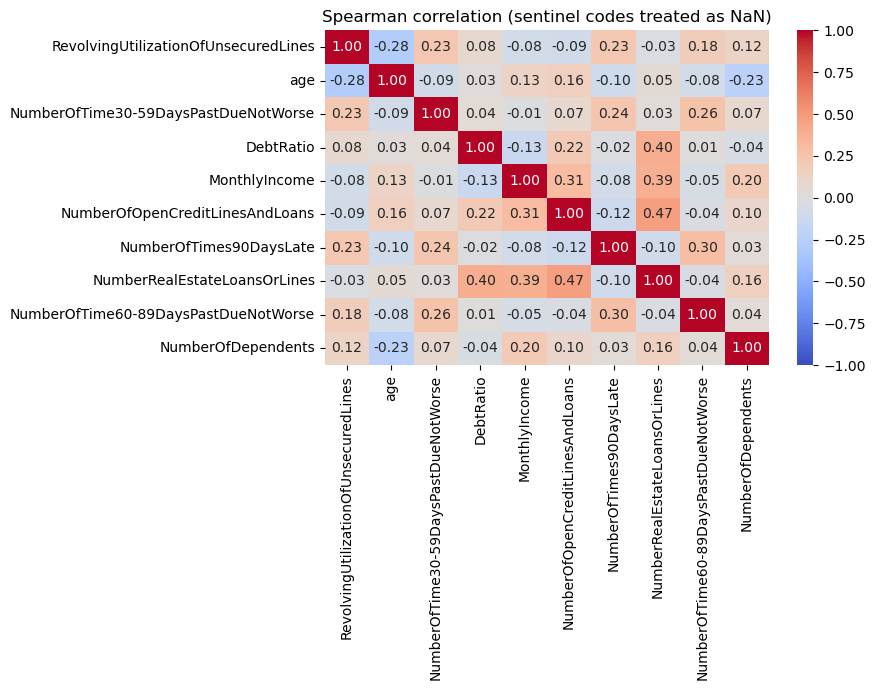

In [16]:
corr = train_clean[feature_cols].corr(method="spearman")
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Spearman correlation (sentinel codes treated as NaN)")
plt.tight_layout()


def vif_manual(df, columns):
    d = df[columns].dropna()
    out = {}
    for c in columns:
        y = d[c].values
        X = np.column_stack([np.ones(len(d)), d[[x for x in columns if x != c]].values])
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        resid = y - X @ beta
        r2 = 1 - resid.var() / y.var()
        out[c] = 1 / (1 - r2) if r2 < 1 else np.inf
    return pd.Series(out, name="VIF").sort_values(ascending=False)


vif_manual(train_clean, feature_cols).to_frame()

## Feature vs. target association

Point-biserial correlation (Pearson-family, sensitive to outliers) alongside a
Mann-Whitney U test (rank-based, robust to outliers) against `SeriousDlqin2yrs`.
Watch `RevolvingUtilizationOfUnsecuredLines` in particular: its point-biserial r is
~0 and not significant, yet the Mann-Whitney test is highly significant and the group
medians differ by 6x. That gap is the outliers (utilization values in the thousands,
vs. a theoretical ceiling near 1-2) swamping the linear correlation — a reminder that a
near-zero Pearson/point-biserial correlation doesn't always mean "not predictive."

,point_biserial_r,point_biserial_p,mannwhitney_p,median | delinquent,median | not delinquent
feature,,,,,
NumberOfTimes90DaysLate,0.314554,0.000000e+00,0.000000e+00,0.000000,0.000000
NumberOfTime30-59DaysPastDueNotWorse,0.274431,0.000000e+00,0.000000e+00,0.000000,0.000000
NumberOfTime60-89DaysPastDueNotWorse,0.268095,0.000000e+00,0.000000e+00,0.000000,0.000000
age,-0.115732,0.000000e+00,0.000000e+00,45.000000,52.000000
NumberOfDependents,0.045786,2.116743e-68,5.229883e-68,0.000000,0.000000
NumberOfOpenCreditLinesAndLoans,-0.030535,3.682462e-32,1.002850e-52,7.000000,8.000000
MonthlyIncome,-0.019814,6.449676e-12,1.736807e-120,4500.000000,5475.000000
DebtRatio,-0.007719,2.849077e-03,2.986751e-14,0.428946,0.364388
NumberRealEstateLoansOrLines,-0.007631,3.184936e-03,1.836486e-41,1.000000,1.000000


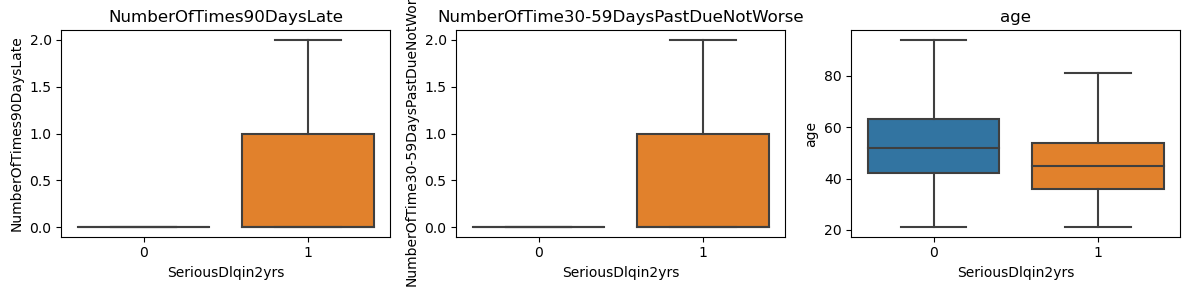

In [17]:
target = train_clean["SeriousDlqin2yrs"]
rows = []
for col in feature_cols:
    vals = train_clean[col]
    mask = vals.notna()
    r, rp = stats.pointbiserialr(target[mask], vals[mask])
    a = vals[mask & (target == 1)]
    b = vals[mask & (target == 0)]
    _, mwu_p = stats.mannwhitneyu(a, b, alternative="two-sided")
    rows.append({
        "feature": col,
        "point_biserial_r": r,
        "point_biserial_p": rp,
        "mannwhitney_p": mwu_p,
        "median | delinquent": a.median(),
        "median | not delinquent": b.median(),
    })

assoc = pd.DataFrame(rows).set_index("feature").sort_values("point_biserial_r", key=abs, ascending=False)
display(assoc)

# Boxplots for the strongest predictors by rank-based association
top_features = ["NumberOfTimes90DaysLate", "NumberOfTime30-59DaysPastDueNotWorse", "age"]
fig, axes = plt.subplots(1, len(top_features), figsize=(4 * len(top_features), 3))
for ax, col in zip(axes, top_features):
    sns.boxplot(x=target, y=train_clean[col], ax=ax, showfliers=False)
    ax.set_title(col)
fig.tight_layout()

## Summary

Full narrative writeup of every test run above (plus the exact counts/thresholds and
the resulting modeling recommendations) lives in
[`EDA_TEST_REPORT.md`](./EDA_TEST_REPORT.md), alongside this notebook.

In [ ]:
sns.boxplot(x=train['SeriousDlqin2yrs'], y=train['RevolvingUtilizationOfUnsecuredLines'], showfliers=False)
plt.title("RevolvingUtilizationOfUnsecuredLines by SeriousDlqin2yrs")

In [47]:
a = train.loc[train['SeriousDlqin2yrs'] == 1, 'RevolvingUtilizationOfUnsecuredLines']
b = train.loc[train['SeriousDlqin2yrs'] == 0, 'RevolvingUtilizationOfUnsecuredLines']
stat, p = stats.mannwhitneyu(a, b, alternative="two-sided")
print(f"median | delinquent: {a.median()}")
print(f"median | not delinquent: {b.median()}")
print(f"Mann-Whitney U p-value: {p}")
print(f"significant (p<0.01): {p < 0.01}")

<IPython.core.display.Javascript object>

median | delinquent: 0.83770214
median | not delinquent: 0.13338398550000002
Mann-Whitney U p-value: 0.0
significant (p<0.01): True


In [ ]:
train[['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines']].corr(method='spearman')